In [1]:
# ── 함수 설명 ──────────────────
# 그래프를 그릴 때 필요한 라이브러리들을 불러오고, 한글 폰트와 데이터를 준비하는 코드
import pandas as pd       # 표(DataFrame) 형태로 데이터를 다루는 라이브러리
import matplotlib.pyplot as plt   # 그래프를 그리는 라이브러리
import matplotlib.font_manager as fm  # 폰트(글꼴) 정보를 다루는 도구
import seaborn as sns     # matplotlib을 기반으로 더 보기 좋은 그래프를 그리는 라이브러리
import os                 # 폴더 경로, 현재 위치 확인 등을 위한 라이브러리

# 한글 폰트 설정 (Mac)
plt.rcParams['font.family'] = 'AppleGothic'
# rcParams: matplotlib의 전체 그래프 설정을 담은 딕셔너리
#   └ 'font.family' = 'AppleGothic' : 그래프 글꼴을 맥용 한글 글꼴로 지정 → 한글이 깨지지 않게 함
plt.rcParams['axes.unicode_minus'] = False
#   └ 'axes.unicode_minus' = False : 음수(-) 기호가 깨져 보이는 문제를 방지

print("현재 위치:", os.getcwd())
# os.getcwd(): 현재 작업 중인 폴더(working directory)의 경로를 반환

os.chdir('/Users/ijaejun/Documents/sophomore_high/crime_catchers')
# os.chdir(경로): 작업 폴더를 지정한 경로로 옮김 → 어디서 실행해도 같은 파일을 찾을 수 있게 함

print("현재 위치:", os.getcwd())

df = pd.read_csv('data/processed/final_data.csv', encoding='utf-8-sig')
# read_csv(): CSV 파일을 표(DataFrame)로 읽어오는 함수
#   └ encoding='utf-8-sig' : 한글이 깨지지 않도록 인코딩 방식을 지정


현재 위치: /Users/ijaejun/Documents/sophomore_high/crime_catchers/notebooks
현재 위치: /Users/ijaejun/Documents/sophomore_high/crime_catchers


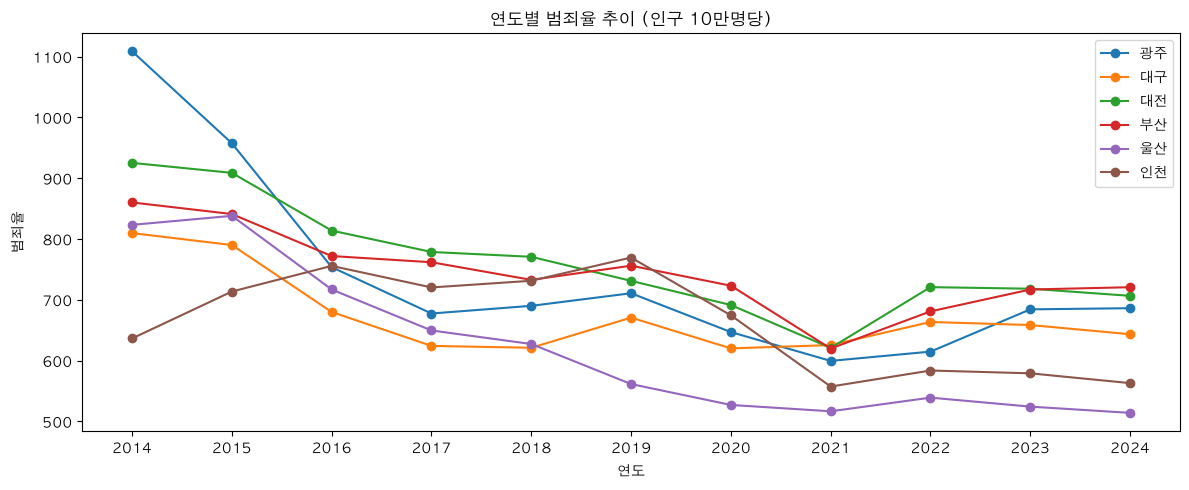

In [2]:
# ── 함수 설명 ──────────────────
# 6개 도시별로 2014~2024년 범죄율 변화를 한 그래프에 선으로 그려서 비교하기 위한 코드
# ── 1. 연도별 범죄율 추이 (도시별) ──────────
plt.figure(figsize=(12, 5))
# figure(): 새 그래프(도화지)를 만드는 함수
#   └ figsize=(12, 5) : 그래프의 가로 12, 세로 5 크기(인치 단위)를 지정

for city in df['지역'].unique():
# unique(): 컬럼에서 중복을 제거한 값들만 모아 배열로 반환 (여기서는 6개 도시 이름)
# for문으로 도시 이름을 하나씩 city에 담아 반복
    d = df[df['지역'] == city]
    # df[df['지역'] == city] : '지역' 컬럼이 city와 같은 행만 골라냄 (조건으로 필터링)
    plt.plot(d['연도'], d['범죄율'], marker='o', label=city)
    # plot(): 선 그래프를 그리는 함수
    #   └ x축에 '연도', y축에 '범죄율' 값을 사용
    #   └ marker='o' : 각 데이터 점을 동그라미(o)로 표시
    #   └ label=city : 범례(legend)에 표시할 이름을 도시명으로 지정

plt.title('연도별 범죄율 추이 (인구 10만명당)')
# title(): 그래프 제목을 설정
plt.xlabel('연도')
# xlabel(): x축 이름을 설정
plt.ylabel('범죄율')
# ylabel(): y축 이름을 설정
plt.xticks(range(2014, 2025))  # ← 이거 추가!
# xticks(): x축에 표시할 눈금(숫자)을 지정
#   └ range(2014, 2025) : 2014부터 2024까지 1년 단위로 모든 연도를 눈금에 표시
plt.legend()
# legend(): 각 선이 어떤 도시를 의미하는지 알려주는 범례(설명 박스)를 표시
plt.tight_layout()
# tight_layout(): 제목, 축 이름 등 그래프 요소들이 겹치지 않도록 여백을 자동으로 맞춤
plt.savefig('visualizations/crime_trend.png', dpi=150)
# savefig(): 그래프를 이미지 파일로 저장
#   └ dpi=150 : 해상도를 150dpi로 지정 (숫자가 클수록 더 선명함)
plt.show()
# show(): 완성된 그래프를 화면에 출력


/var/folders/cg/vhchl3156fq3fl9yhk7kx8z00000gn/T/ipykernel_98338/12301841.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_avg.index, y=city_avg.values, palette='Blues_r')


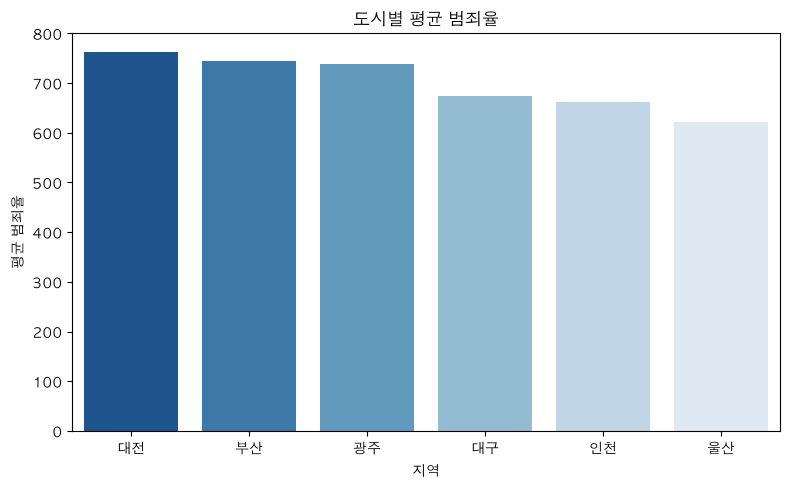

In [3]:
# ── 함수 설명 ──────────────────
# 6개 도시의 2014~2024년 평균 범죄율을 계산해서 막대그래프로 비교하기 위한 코드
# ── 2. 도시별 평균 범죄율 비교 ───────────────
plt.figure(figsize=(8, 5))
# figure(): 새 그래프를 만들고 크기를 가로 8, 세로 5(인치)로 지정

city_avg = df.groupby('지역')['범죄율'].mean().sort_values(ascending=False)
# groupby('지역'): '지역' 컬럼 값이 같은 행들을 하나의 그룹으로 묶음
# ['범죄율'].mean(): 그룹별로 '범죄율'의 평균값을 계산
# sort_values(ascending=False): 평균값이 큰 도시부터 작은 도시 순으로 정렬
#   └ ascending=False : 내림차순(큰 값 → 작은 값)으로 정렬

sns.barplot(x=city_avg.index, y=city_avg.values, palette='Blues_r')
# barplot(): 막대그래프를 그리는 함수
#   └ x=city_avg.index : x축에 도시 이름들을 표시
#   └ y=city_avg.values : y축에 각 도시의 평균 범죄율 값을 표시
#   └ palette='Blues_r' : 막대 색을 파란색 계열로 지정 ('Blues_r'은 진한 파랑→연한 파랑 순서)

plt.title('도시별 평균 범죄율')
# title(): 그래프 제목을 설정
plt.ylabel('평균 범죄율')
# ylabel(): y축 이름을 설정
plt.tight_layout()
# tight_layout(): 그래프 요소들이 겹치지 않도록 여백을 자동으로 맞춤
plt.savefig('visualizations/crime_by_city.png', dpi=150)
# savefig(): 그래프를 이미지 파일로 저장 (dpi=150: 해상도 지정)
plt.show()
# show(): 완성된 그래프를 화면에 출력


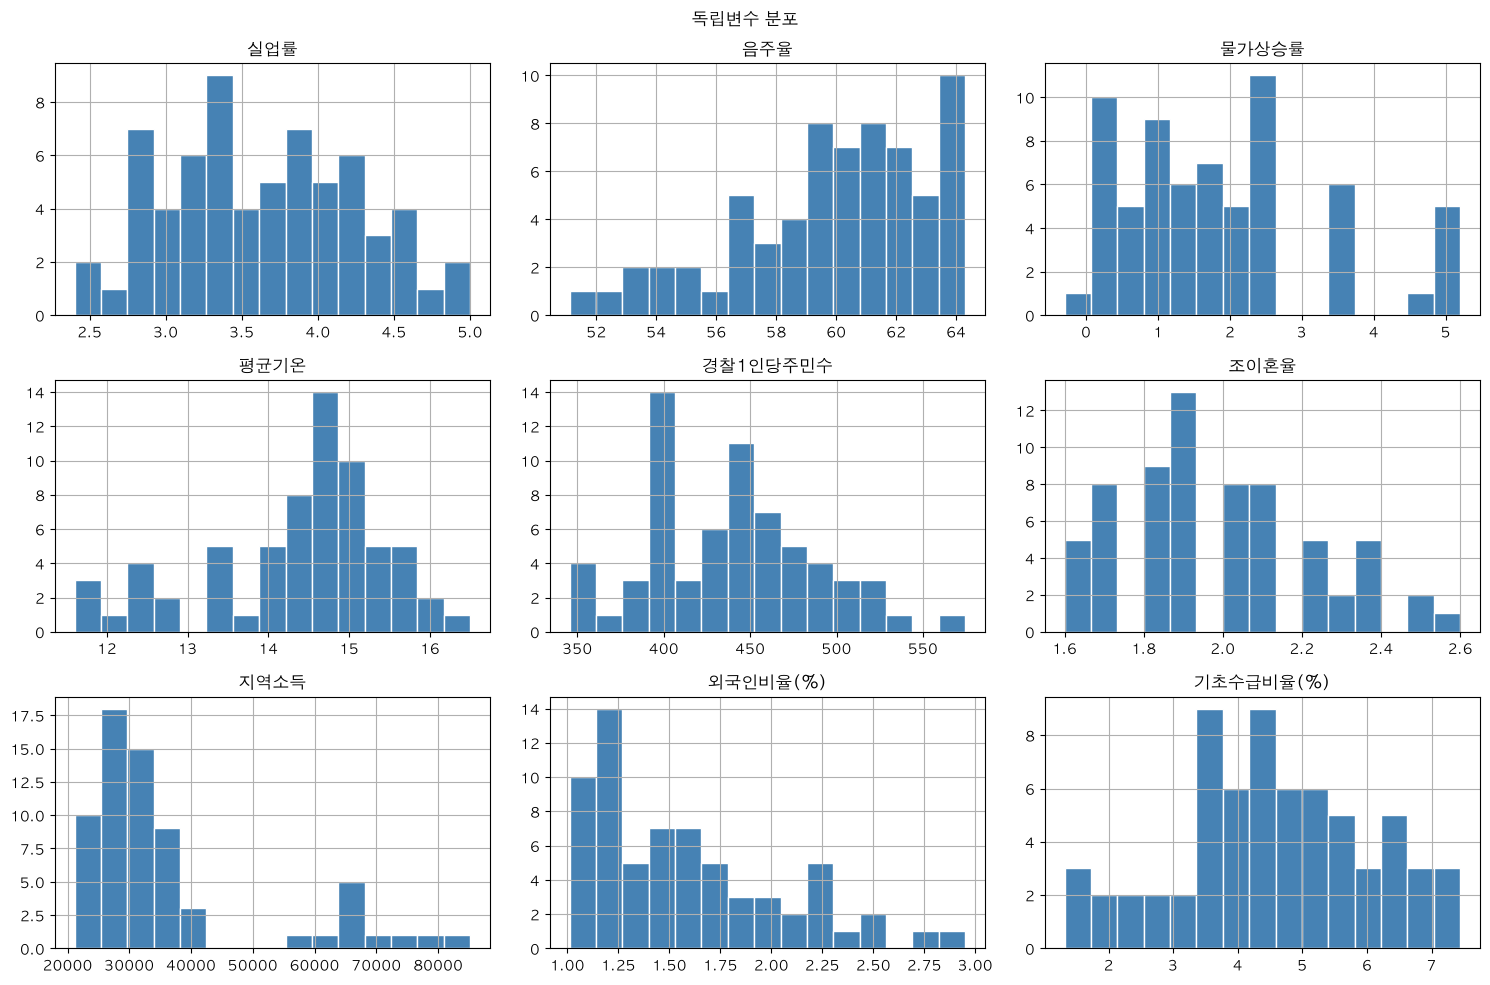

✅ EDA 완료! visualizations 폴더 확인하세요!


In [4]:
# ── 함수 설명 ──────────────────
# 회귀분석에서 사용할 독립변수 9개가 각각 어떤 값 범위에 많이 모여있는지(분포) 히스토그램으로 확인하는 코드
# ── 3. 독립변수 분포 확인 ─────────────────────
feature_cols = ['실업률', '음주율', '물가상승률', '평균기온',
                '경찰1인당주민수', '조이혼율', '지역소득',
                '외국인비율(%)', '기초수급비율(%)']
# 분포를 확인할 독립변수 9개의 컬럼 이름 목록

df[feature_cols].hist(figsize=(15, 10), bins=15, color='steelblue', edgecolor='white')
# hist(): 각 컬럼마다 히스토그램(값의 분포를 보여주는 막대그래프)을 그리는 함수
#   └ figsize=(15, 10) : 전체 그림의 크기를 가로 15, 세로 10(인치)으로 지정
#   └ bins=15 : 값의 구간(막대)을 15개로 나눔
#   └ color='steelblue' : 막대의 색을 steelblue(짙은 청색)로 지정
#   └ edgecolor='white' : 막대 테두리를 흰색으로 지정해 막대 구분이 잘 보이게 함

plt.suptitle('독립변수 분포')
# suptitle(): 여러 개의 작은 그래프를 모아놓은 전체 그림에 공통 제목을 붙임
plt.tight_layout()
# tight_layout(): 그래프들이 서로 겹치지 않도록 여백을 자동으로 맞춤
plt.savefig('visualizations/feature_dist.png', dpi=150)
# savefig(): 그래프를 이미지 파일로 저장 (dpi=150: 해상도 지정)
plt.show()
# show(): 완성된 그래프를 화면에 출력

print("✅ EDA 완료! visualizations 폴더 확인하세요!")
# print(): 작업이 끝났음을 알리는 메시지를 출력
